# GR Prediction — Star-Ablation Comparison (frontend · conditioning · head)

Side-by-side eval of the four cells of the GR-prediction star ablation on the **same**
metric engine, split policy and held-out test set, so the numbers are directly comparable.
Every variant changes exactly **one** axis relative to the base, so each pairwise read is a
single-variable comparison:

| Cell | Frontend | Conditioning | Head | Trained by |
|---|---|---|---|---|
| **base (detector)** | fixed 8-τ detector bank | FiLM+GLU (poly 3) | dB regression | [`train_lstm_detector_gr.ipynb`](train_lstm_detector_gr.ipynb) |
| **F1 (blackbox)** | **learned conv** | FiLM+GLU (poly 3) | dB regression | [`train_lstm_blackbox_gr.ipynb`](train_lstm_blackbox_gr.ipynb) |
| **C1 (concat)** | fixed 8-τ detector bank | **knob concat at LSTM input** | dB regression | [`train_lstm_concat_gr.ipynb`](train_lstm_concat_gr.ipynb) |
| **O1 (bins)** | fixed 8-τ detector bank | FiLM+GLU (poly 3) | **71-bin discretized (clean)** | [`train_lstm_bins_gr.ipynb`](train_lstm_bins_gr.ipynb) |

**Deliberately excluded** (hard-blocked in ── 1, `EXCLUDED_RUNS`):

- the predecessor bins run (`lstm_gr_20260611_132730_…_bins_lds_cdrop_coldstart`) — it changed
  frontend + conditioning + head + training machinery at once, so nothing is attributable;
  O1 replaces it with a bins head on the otherwise-unchanged base.
- the v1 knob-concat run (`lstm_gr_20260702_174039_lstm_detector_gr`) — contaminated split
  (`test_ground_truth` pairs inside train/val), its test numbers are invalid; C1 replaces it
  on the honest v2 split.

Sections:

- **── 6** scores the **validation split** (each run's held-out song × all settings) for all models.
- **── 7** scores the held-out **TEST set** (`test_ground_truth/`, unseen songs + mostly unseen
  settings) for all models, and **adds model-size columns** (param count + checkpoint size).
- **── 8** is the **ablation verdict**: the val→test gap table plus one single-variable read per axis.

The canonical **9-column engine** (`GR MAE (dB)`, `MR-STE`, `MR-STFT`, `ESR (A-wt)`,
`MAE (L1)`, `MSE (L2)`, `EDC`, `M_NRMSE`, `M_SF`) is ported unchanged from the solo evals.
Every model predicts a GR curve; wet audio is **reconstructed** as `dry × 10^(GR_dB/20)` before scoring.

> Requirements: `uv sync` at repo root. Run after all Colab run dirs have synced to Drive.
> This notebook lives in `05_conditioning/` so the bare `model*`/`splits`/`gr_target` imports resolve.


In [1]:
# ── 0. Imports and defaults ─────────────────────────────────────────

import gc, glob, json, os, sys, types, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

warnings.filterwarnings("ignore", category=UserWarning)

# stub `rational` so the optional nablafx verification import can't drag in broken wheels
rational = types.ModuleType("rational")
rational.torch = types.ModuleType("rational.torch")
rational.torch.Rational = type("Rational", (), {})
sys.modules["rational"], sys.modules["rational.torch"] = rational, rational.torch

sys.path.insert(0, str(Path.cwd().parent / "03_initial_GR_pred"))  # shared eval helpers

from src.dsp_torch import RMS_WINDOW, gain_reduction_db
from gr_target import GR_DB_MIN, GR_DB_MAX, NUM_BINS, BIN_RESOLUTION_DB
from model_detector_gr import DetectorGRLSTM
from model_blackbox_gr import BlackboxGRLSTM
from model_bins_gr import BinsGRLSTM
from model_concat_gr import ConcatGRLSTM
from splits import DIFFSSL_PARAM_RANGES, SplitManifest, normalize_setting_params
from eval_helpers import (
    _checkpoint_sort_key, _db_to_amplitude, _find_hparams_json, _pair_num_frames,
    _read_dry_wet_segment, _weighted_average_metric_rows, latest_best_checkpoint,
    list_runs, wet_dir_for_setting,
)

DATA_ROOT = "/Volumes/Saola's Drive/AllCode/thesis/data/Diff-SSL-G-Comp"
RUNS_DIR = "/Volumes/Saola's Drive/AllCode/thesis/data/gr_pred_runs"
SAMPLE_RATE = 44100
DEVICE = "cpu"

print(f"torch {torch.__version__}  |  device: {DEVICE}")
print(f"GR range: [{GR_DB_MIN}, {GR_DB_MAX}] dB")


torch 2.10.0  |  device: cpu
GR range: [-30.0, 5.0] dB


In [2]:
# ── 1. Model registry + run selection (one run per ablation cell) ────
# Each ablation cell is loaded from its own most-recently-modified run.
# Override a specific run by setting its entry in SELECTED_RUNS to the run
# name. EXCLUDED_RUNS are never eligible — see the header for why each one
# is out.

EXCLUDED_RUNS = {
    "lstm_gr_20260702_174039_lstm_detector_gr",                       # v1 knob-concat: contaminated split
    "lstm_gr_20260611_132730_lstm_condlstm_bins_lds_cdrop_coldstart", # predecessor bins: 4 confounds at once
}

SELECTED_RUNS: dict[str, str | None] = {
    "detector": None,   # -> newest detector_gr_lstm_film run    (base: FiLM+GLU, regression)
    "blackbox": None,   # -> newest blackbox_gr_lstm_film run    (F1: learned frontend)
    "concat":   None,   # -> newest detector_gr_lstm_concat run  (C1: knob-concat conditioning)
    "bins":     None,   # -> newest detector_gr_lstm_bins run    (O1: clean discretized head)
}


def _load_detector(hp, ckpt_path):
    m = hp["model"]
    model = DetectorGRLSTM(
        hop_size=int(hp["hop_size"]),
        sample_rate=int(hp["sample_rate"]),
        detector_taus_ms=tuple(m["detector_taus_ms"]),
        detector_kernel_frames=int(m["detector_kernel_frames"]),
        detector_learnable=bool(m.get("detector_learnable", False)),
        hidden_size=int(m["hidden_size"]),
        film_order=int(m["film_order"]),
    )
    fixed = "learnable" if m.get("detector_learnable", False) else "fixed"
    taus = [round(float(v), 1) for v in m["detector_taus_ms"]]
    desc = f"{fixed} detector τ={taus} ms, FiLM order={m['film_order']}"
    return model, desc


def _load_blackbox(hp, ckpt_path):
    m = hp["model"]
    model = BlackboxGRLSTM(
        hop_size=int(hp["hop_size"]),
        sample_rate=int(hp["sample_rate"]),
        enc_channels=int(m["enc_channels"]),
        frontend_channels=int(m["frontend_channels"]),
        temporal_kernel=int(m["temporal_kernel"]),
        temporal_dilations=tuple(int(d) for d in m["temporal_dilations"]),
        hidden_size=int(m["hidden_size"]),
        film_order=int(m["film_order"]),
    )
    rf = model.temporal_context + 1
    desc = (f"learned frontend enc={m['enc_channels']}ch, dilations={list(m['temporal_dilations'])}, "
            f"RF {rf} frames ~= {rf * model.hop_size / int(hp['sample_rate']):.2f} s, "
            f"FiLM order={m['film_order']}")
    return model, desc


def _load_concat(hp, ckpt_path):
    m = hp["model"]
    model = ConcatGRLSTM(
        hop_size=int(hp["hop_size"]),
        sample_rate=int(hp["sample_rate"]),
        detector_taus_ms=tuple(m["detector_taus_ms"]),
        detector_kernel_frames=int(m["detector_kernel_frames"]),
        detector_learnable=bool(m.get("detector_learnable", False)),
        hidden_size=int(m["hidden_size"]),
    )
    taus = [round(float(v), 1) for v in m["detector_taus_ms"]]
    desc = f"knob-concat at LSTM input (no FiLM/GLU), fixed detector τ={taus} ms"
    return model, desc


def _load_bins(hp, ckpt_path):
    m = hp["model"]
    d = hp.get("discretization", {})
    num_bins = int(d.get("num_bins", m.get("num_bins", NUM_BINS)))
    model = BinsGRLSTM(
        hop_size=int(hp["hop_size"]),
        sample_rate=int(hp["sample_rate"]),
        detector_taus_ms=tuple(m["detector_taus_ms"]),
        detector_kernel_frames=int(m["detector_kernel_frames"]),
        detector_learnable=bool(m.get("detector_learnable", False)),
        hidden_size=int(m["hidden_size"]),
        film_order=int(m["film_order"]),
        num_bins=num_bins,
    )
    desc = (f"clean bins head {num_bins}@{BIN_RESOLUTION_DB:.2f} dB (no LDS/CFG), "
            f"detector frontend, FiLM order={m['film_order']}")
    return model, desc


MODEL_REGISTRY = {
    "detector": {"type": "detector_gr_lstm_film", "label": "detector (base: FiLM+GLU, regression)",
                 "loader": _load_detector, "color": "#1f77b4"},
    "blackbox": {"type": "blackbox_gr_lstm_film", "label": "blackbox (F1: learned frontend)",
                 "loader": _load_blackbox, "color": "#d62728"},
    "concat": {"type": "detector_gr_lstm_concat", "label": "concat (C1: knob-concat cond)",
               "loader": _load_concat, "color": "#ff7f0e"},
    "bins": {"type": "detector_gr_lstm_bins", "label": "bins (O1: discretized head)",
             "loader": _load_bins, "color": "#2ca02c"},
}

runs_df = list_runs(RUNS_DIR)
assert not runs_df.empty, f"No runs in {RUNS_DIR}"
runs_df = runs_df[~runs_df["run"].isin(EXCLUDED_RUNS)]

for key, spec in MODEL_REGISTRY.items():
    cand = runs_df[runs_df["type"] == spec["type"]]
    assert not cand.empty, f"No '{spec['type']}' runs in {RUNS_DIR} — train it first."
    want = SELECTED_RUNS.get(key)
    if want:
        assert want not in EXCLUDED_RUNS, f"{key}: {want} is excluded (not comparable)"
        rows = cand[cand["run"] == want]
        assert len(rows) == 1, f"{key}: run not found: {want}"
        spec["run_row"] = rows.iloc[0]
    else:
        spec["run_row"] = cand.iloc[-1]   # list_runs sorts by mtime asc

sel = pd.DataFrame([
    {"key": k, "label": s["label"], "run": s["run_row"]["run"],
     "epoch": s["run_row"].get("epoch"), "best_val": s["run_row"].get("best_val"),
     "eval_ckpt": s["run_row"].get("eval_ckpt")}
    for k, s in MODEL_REGISTRY.items()
])
print("Selected runs:")
display(sel)


Selected runs:


,key,label,run,epoch,best_val,eval_ckpt
0,detector,"detector (base: FiLM+GLU, regression)",lstm_gr_20260704_132800_lstm_detector_gr_film,150.0,0.101750,best-098-49500.ckpt
1,blackbox,blackbox (F1: learned frontend),lstm_gr_20260705_125142_lstm_blackbox_gr_film,150.0,0.104465,best-081-41000.ckpt
2,concat,concat (C1: knob-concat cond),lstm_gr_20260705_153642_lstm_detector_gr_concat,150.0,0.091270,best-090-45500.ckpt
3,bins,bins (O1: discretized head),lstm_gr_20260705_154513_lstm_detector_gr_bins,150.0,0.093686,best-099-50000.ckpt


In [3]:
# ── 2. Resolve run dirs, checkpoints, split manifests, test set ──────
# All runs share the SAME external held-out test set (test_ground_truth/), and
# each keeps its own split_manifest.json for its validation pairs. The
# test_ground_truth folder is the ONLY test set under the v2 split policy; cell
# ── 2 re-asserts every run's manifest is disjoint from it (the v1 detector run
# lstm_gr_20260702_174039 failed this — 4 test pairs in train, 1 in val).

TEST_GT_DIR = os.path.join(DATA_ROOT, "test_ground_truth")
assert os.path.isdir(TEST_GT_DIR), f"Missing held-out test set: {TEST_GT_DIR}"


def discover_test_pairs(test_gt_dir: str = TEST_GT_DIR) -> list[tuple[str, str]]:
    """(song, setting) pairs under test_ground_truth that have a dry match."""
    dry_dir = os.path.join(DATA_ROOT, "processed_normalized")
    pairs, missing = [], []
    for setting in sorted(os.listdir(test_gt_dir)):
        sdir = os.path.join(test_gt_dir, setting)
        if not os.path.isdir(sdir) or not setting.startswith("threshold_"):
            continue
        for wet in sorted(glob.glob(os.path.join(sdir, "*-exported.wav"))):
            song = os.path.basename(wet).replace("-exported.wav", "")
            dry = os.path.join(dry_dir, f"{song}_UnmasteredWAV.wav")
            (pairs if os.path.isfile(dry) else missing).append((song, setting))
    if missing:
        print(f"[warning] {len(missing)} test wet files have no dry match (skipped): {missing}")
    return pairs


TEST_PAIRS = discover_test_pairs()
_test_keys = {f"{song}::{setting}" for song, setting in TEST_PAIRS}


def pair_paths(setting: str, song: str) -> tuple[str, str]:
    """Dry + wet paths; wet resolves across train exports AND test_ground_truth."""
    dry = os.path.join(DATA_ROOT, "processed_normalized", f"{song}_UnmasteredWAV.wav")
    candidates = [
        os.path.join(DATA_ROOT, setting, f"{song}-exported.wav"),
        os.path.join(DATA_ROOT, "processed_ground_truth", setting, f"{song}-exported.wav"),
        os.path.join(TEST_GT_DIR, setting, f"{song}-exported.wav"),
    ]
    for wet in candidates:
        if os.path.isfile(wet):
            return dry, wet
    return dry, candidates[1]   # non-existent path — callers existence-check


def _pairs_from_keys(keys) -> list[tuple[str, str]]:
    return [tuple(k.split("::")) for k in sorted(keys)]   # (song, setting)


def _filter_local(pairs, label):
    """Drop pairs whose dry/wet audio has not synced to the local dataset."""
    ok, missing = [], []
    for song, setting in pairs:
        dry, wet = pair_paths(setting, song)
        (ok if os.path.isfile(dry) and os.path.isfile(wet) else missing).append((song, setting))
    if missing:
        print(f"[warning] {label}: skipping {len(missing)}/{len(pairs)} pairs with no local dry/wet")
    return ok


for key, spec in MODEL_REGISTRY.items():
    run_name = str(spec["run_row"]["run"])
    run_dir = os.path.join(RUNS_DIR, run_name)
    with open(os.path.join(run_dir, "hparams.json")) as f:
        hp = json.load(f)
    split = SplitManifest.load(os.path.join(run_dir, "split_manifest.json"))

    # normalisation guards — see NORMALISATION.md
    assert tuple(hp["gr_range_db"]) == (GR_DB_MIN, GR_DB_MAX), hp["gr_range_db"]
    assert {k: tuple(v) for k, v in hp["param_ranges"].items()} == DIFFSSL_PARAM_RANGES
    assert hp.get("model_type") == spec["type"], hp.get("model_type")

    # contamination guard — held-out test set must be disjoint from train/val
    leaked = (set(split.train_pair_keys) | set(split.val_pair_keys)) & _test_keys
    assert not leaked, (
        f"CONTAMINATED RUN {run_name}: test_ground_truth pairs inside train/val: "
        f"{sorted(leaked)} — its test numbers would be invalid.")

    spec.update({
        "run_name": run_name, "run_dir": run_dir, "hp": hp, "split": split,
        "ckpt": latest_best_checkpoint(run_dir),
        "val_pairs": _filter_local(_pairs_from_keys(split.val_pair_keys), f"{key} validation"),
    })

print(f"Held-out test pairs (shared, test_ground_truth): {len(TEST_PAIRS)}")
for key, spec in MODEL_REGISTRY.items():
    print(f"  {spec['label']:<28} run={spec['run_name']}")
    print(f"      ckpt={os.path.basename(spec['ckpt'])}  "
          f"val pairs={len(spec['val_pairs'])} ({spec['split'].val_songs})")


Held-out test pairs (shared, test_ground_truth): 5
  detector (base: FiLM+GLU, regression) run=lstm_gr_20260704_132800_lstm_detector_gr_film
      ckpt=best-098-49500.ckpt  val pairs=10 (['AncoraQui'])
  blackbox (F1: learned frontend) run=lstm_gr_20260705_125142_lstm_blackbox_gr_film
      ckpt=best-081-41000.ckpt  val pairs=10 (['AncoraQui'])
  concat (C1: knob-concat cond) run=lstm_gr_20260705_153642_lstm_detector_gr_concat
      ckpt=best-090-45500.ckpt  val pairs=10 (['AncoraQui'])
  bins (O1: discretized head)  run=lstm_gr_20260705_154513_lstm_detector_gr_bins
      ckpt=best-099-50000.ckpt  val pairs=10 (['AncoraQui'])


In [4]:
# ── 3. Load both models + record model sizes ─────────────────────────
# Params = sum(p.numel()); disk = eval checkpoint size on disk. Both feed the
# model-size columns of the ── 7 test table.

def _fmt_bytes(n):
    return f"{n / 1e6:.2f} MB"

MODELS = {}
size_rows = []
for key, spec in MODEL_REGISTRY.items():
    model, desc = spec["loader"](spec["hp"], spec["ckpt"])
    sd = torch.load(spec["ckpt"], map_location=DEVICE, weights_only=False)["state_dict"]
    model.load_state_dict({k[len("model."):]: v for k, v in sd.items() if k.startswith("model.")})
    model.to(DEVICE).eval()

    n_params = sum(p.numel() for p in model.parameters())
    n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    ckpt_bytes = os.path.getsize(spec["ckpt"])
    spec["model"] = model
    spec["n_params"] = n_params
    spec["ckpt_bytes"] = ckpt_bytes
    MODELS[key] = model

    print(f"Loaded {spec['label']:<28} {n_params:>7,} params  ({desc})")
    size_rows.append({
        "Model": spec["label"], "Run": spec["run_name"],
        "Params": n_params, "Trainable": n_trainable,
        "Ckpt size": _fmt_bytes(ckpt_bytes),
    })

# both models share sample rate + rms window (asserted-compatible above)
RMS_WIN = int(MODEL_REGISTRY["detector"]["hp"].get("rms_window", RMS_WINDOW))
SR = SAMPLE_RATE
model_sizes_df = pd.DataFrame(size_rows)
print(f"\nReference-GR RMS window: {RMS_WIN}")
display(model_sizes_df)


Loaded detector (base: FiLM+GLU, regression)   7,841 params  (fixed detector τ=[2.0, 5.0, 11.0, 26.0, 61.0, 144.0, 340.0, 800.0] ms, FiLM order=3)
Loaded blackbox (F1: learned frontend)  16,249 params  (learned frontend enc=16ch, dilations=[1, 4, 16, 64], RF 256 frames ~= 1.49 s, FiLM order=3)
Loaded concat (C1: knob-concat cond)   5,921 params  (knob-concat at LSTM input (no FiLM/GLU), fixed detector τ=[2.0, 5.0, 11.0, 26.0, 61.0, 144.0, 340.0, 800.0] ms)
Loaded bins (O1: discretized head)   10,151 params  (clean bins head 71@0.50 dB (no LDS/CFG), detector frontend, FiLM order=3)

Reference-GR RMS window: 1024


,Model,Run,Params,Trainable,Ckpt size
0,"detector (base: FiLM+GLU, regression)",lstm_gr_20260704_132800_lstm_detector_gr_film,7841,7841,0.11 MB
1,blackbox (F1: learned frontend),lstm_gr_20260705_125142_lstm_blackbox_gr_film,16249,16249,0.22 MB
2,concat (C1: knob-concat cond),lstm_gr_20260705_153642_lstm_detector_gr_concat,5921,5921,0.08 MB
3,bins (O1: discretized head),lstm_gr_20260705_154513_lstm_detector_gr_bins,10151,10151,0.14 MB


In [5]:
# ── 4. Metric engine (ported verbatim from the solo evals) ───────────
# Identical 9-column engine to eval_lstm_detector_gr / eval_lstm_blackbox_gr /
# eval_lstm_gain_prior, so numbers are directly comparable across models and
# notebooks. Every moving-average envelope uses an O(N) cumsum window; the FFT
# metrics reimplement auraloss MultiResolutionSTFTLoss and src.losses.{M_SF, EDC},
# batched. MR-STFT / ESR verified against nablafx.evaluation (auraloss).

from scipy.signal import bilinear, lfilter

EPS = 1e-10

MR_STE_WINDOWS   = (256, 1024, 4096)
MR_NRMSE_WINDOWS = (512, 1024, 2048)
STFT_SIZES       = (512, 1024, 2048)
_MRSTFT_RES      = [(1024, 120, 600), (2048, 240, 1200), (512, 50, 240)]

METRIC_COLS = [
    "GR MAE (dB)", "MR-STE",
    "MR-STFT", "ESR (A-wt)",
    "MAE (L1)", "MSE (L2)", "EDC", "M_NRMSE", "M_SF",
]


def _moving_meansq(x_sq, W, centered):
    n = x_sq.shape[-1]
    c = np.empty(n + 1); c[0] = 0.0; np.cumsum(x_sq, out=c[1:])
    i = np.arange(n)
    if centered:
        lo = i - (W // 2); hi = lo + W
    else:
        hi = i + 1; lo = hi - W
    lo = np.clip(lo, 0, n); hi = np.clip(hi, 0, n)
    return (c[hi] - c[lo]) / np.maximum(hi - lo, 1)

def _to_db(x):       return 20.0 * np.log10(np.maximum(x, EPS))
def _esr(pred, tgt): return float(np.sum((tgt - pred) ** 2) / (np.sum(tgt * tgt) + 1e-8))

def _a_weighting_ba(fs):
    f1, f2, f3, f4 = 20.598997, 107.65265, 737.86223, 12194.217
    A1000 = 1.9997
    nums = [(2 * np.pi * f4) ** 2 * 10 ** (A1000 / 20.0), 0, 0, 0, 0]
    dens = np.polymul([1, 4 * np.pi * f4, (2 * np.pi * f4) ** 2],
                      [1, 4 * np.pi * f1, (2 * np.pi * f1) ** 2])
    dens = np.polymul(np.polymul(dens, [1, 2 * np.pi * f3]), [1, 2 * np.pi * f2])
    return bilinear(nums, dens, fs)
AW_B, AW_A = _a_weighting_ba(SR)


def reference_gr_db(dry, wet, W=RMS_WIN):
    return (_to_db(np.sqrt(_moving_meansq(wet * wet, W, centered=False)))
            - _to_db(np.sqrt(_moving_meansq(dry * dry, W, centered=False))))


def mr_ste(pred, wet, windows=MR_STE_WINDOWS):
    pe, we = pred * pred, wet * wet
    total = 0.0
    for W in windows:
        ep = _moving_meansq(pe, W, centered=True)
        et = _moving_meansq(we, W, centered=True)
        total += np.sum(np.abs(ep - et)) / (np.sum(np.abs(et)) + 1e-8)
    return float(total / len(windows))

def mr_nrmse(pred, wet, windows=MR_NRMSE_WINDOWS):
    total = 0.0
    for W in windows:
        rp = np.sqrt(_moving_meansq(pred * pred, W, centered=False))
        rt = np.sqrt(_moving_meansq(wet * wet, W, centered=False))
        total += np.sqrt(np.mean((rt - rp) ** 2)) / (np.sqrt(np.mean(rt * rt)) + 1e-8)
    return float(total / len(windows))


_HANN = {}
def _win(n):
    if n not in _HANN:
        _HANN[n] = torch.hann_window(n)
    return _HANN[n]

def _stft_mag_pow(x2d, n_fft, hop, win):
    st = torch.stft(x2d, n_fft=n_fft, hop_length=hop, win_length=win,
                    window=_win(win), return_complex=True)
    return torch.sqrt(torch.clamp(st.real ** 2 + st.imag ** 2, min=1e-8))

def _stft_mag_fft(x2d, n_fft):
    return torch.stft(x2d, n_fft=n_fft, hop_length=n_fft // 4,
                      window=_win(n_fft), return_complex=True).abs()

@torch.no_grad()
def fft_metrics(pred1d: torch.Tensor, wet1d: torch.Tensor) -> dict:
    P1, T1 = pred1d.unsqueeze(0), wet1d.unsqueeze(0)
    out = {}
    acc = 0.0
    for n_fft, hop, win in _MRSTFT_RES:
        P = _stft_mag_pow(P1, n_fft, hop, win)[0]
        T = _stft_mag_pow(T1, n_fft, hop, win)[0]
        sc = torch.linalg.norm(T - P) / torch.linalg.norm(T)
        lm = (torch.log(P) - torch.log(T)).abs().mean()
        acc += float(sc + lm)
    out["MR-STFT"] = acc / len(_MRSTFT_RES)

    sf = 0.0
    for n_fft in STFT_SIZES:
        P = _stft_mag_fft(P1, n_fft)[0]
        T = _stft_mag_fft(T1, n_fft)[0]
        pf, tf = torch.diff(P, dim=-1), torch.diff(T, dim=-1)
        sf += float((tf - pf).abs().mean() / (tf.abs().mean() + 1e-8))
    out["M_SF"] = sf / len(STFT_SIZES)

    pe = torch.flip(torch.cumsum(torch.flip(P1 ** 2, dims=(-1,)), dim=-1), dims=(-1,))
    te = torch.flip(torch.cumsum(torch.flip(T1 ** 2, dims=(-1,)), dim=-1), dims=(-1,))
    pe = pe / (pe[..., :1] + 1e-8); te = te / (te[..., :1] + 1e-8)
    out["EDC"] = float((10 * torch.log10(te.clamp(min=1e-8))
                        - 10 * torch.log10(pe.clamp(min=1e-8))).abs().mean())
    return out


def chunk_metrics(dry: np.ndarray, pred: np.ndarray, wet: np.ndarray) -> dict:
    gr_tgt  = np.clip(reference_gr_db(dry, wet),  GR_DB_MIN, GR_DB_MAX)
    gr_pred = np.clip(reference_gr_db(dry, pred), GR_DB_MIN, GR_DB_MAX)
    row = {
        "GR MAE (dB)": float(np.mean(np.abs(gr_pred - gr_tgt))),
        "MR-STE":      mr_ste(pred, wet),
        "ESR (A-wt)":  _esr(lfilter(AW_B, AW_A, pred), lfilter(AW_B, AW_A, wet)),
        "MAE (L1)":    float(np.mean(np.abs(pred - wet))),
        "MSE (L2)":    float(np.mean((pred - wet) ** 2)),
        "M_NRMSE":     mr_nrmse(pred, wet),
    }
    row.update(fft_metrics(torch.from_numpy(pred).float(),
                           torch.from_numpy(wet).float()))
    return row


# ── verify MR-STFT / ESR against nablafx.evaluation (auraloss) ──
try:
    from nablafx.evaluation import get_function
    _g = torch.Generator().manual_seed(0)
    _p = torch.randn(SR, generator=_g); _t = torch.randn(SR, generator=_g)
    _nab_mrstft, _nab_esr = get_function("mrstft_loss"), get_function("esr_loss")
    _pt, _tt = _p.view(1, 1, -1), _t.view(1, 1, -1)
    _fm = fft_metrics(_p, _t)
    _d_mrstft = abs(float(_nab_mrstft(_pt, _tt)) - _fm["MR-STFT"])
    _d_esr = abs(float(_nab_esr(_pt, _tt)) - _esr(_p.double().numpy(), _t.double().numpy()))
    assert _d_mrstft < 1e-3, _d_mrstft
    assert _d_esr < 1e-4, _d_esr
    print(f"nablafx.evaluation verified — MR-STFT Δ={_d_mrstft:.2e}, ESR Δ={_d_esr:.2e}")
except Exception as e:
    print(f"nablafx verification skipped: {e}")

print(f"Metric engine registered — {len(METRIC_COLS)} columns: {METRIC_COLS}")


/Volumes/Saola's Drive/AllCode/thesis/Virtual-Analogue-Compressor-Modelling/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


nablafx.evaluation verified — MR-STFT Δ=0.00e+00, ESR Δ=5.61e-08
Metric engine registered — 9 columns: ['GR MAE (dB)', 'MR-STE', 'MR-STFT', 'ESR (A-wt)', 'MAE (L1)', 'MSE (L2)', 'EDC', 'M_NRMSE', 'M_SF']


In [6]:
# ── 5. Streaming metric pass (per model, whole song, exact) ──────────
# Streams each (song, setting) pair whole-song in NON-overlapping chunks with the
# model's explicit state carried across chunks — exact vs a single full forward.
# The model predicts a GR curve; wet audio is reconstructed as dry * 10**(GR_dB/20)
# and each chunk scored with chunk_metrics (── 4). Duration-weighted aggregation.

STREAM_CHUNK_SEC = 10.0
MIN_METRIC_FRAMES = max(STFT_SIZES)   # skip sub-FFT tail chunks (torch.stft needs >= n_fft)


@torch.no_grad()
def stream_pair_metrics(model, song: str, setting: str) -> list[dict]:
    # all four models share the stateless (dry, params, state) contract at hop rate
    step = model.hop_size
    chunk_frames = max(step, (int(round(STREAM_CHUNK_SEC * SR)) // step) * step)
    dry_path, wet_path = pair_paths(setting, song)
    params = torch.tensor([normalize_setting_params(setting)], dtype=torch.float32).to(DEVICE)
    total = _pair_num_frames(dry_path, wet_path, SR)
    state, rows = None, []
    for ci, o in enumerate(range(0, total, chunk_frames), start=1):
        dry, wet = _read_dry_wet_segment(dry_path, wet_path, o, min(o + chunk_frames, total), SR)
        L = dry.shape[-1] - (dry.shape[-1] % step)
        if L < step:
            break
        dry, wet = dry[..., :L], wet[..., :L]
        gr, state = model(dry.unsqueeze(0).to(DEVICE), params, state, return_state=True)
        gr_db = model.to_db(gr, sample_len=L).squeeze(0).cpu()
        pred_wet = dry * _db_to_amplitude(gr_db)
        if L < MIN_METRIC_FRAMES:
            continue
        d = dry.squeeze(0).double().cpu().numpy()
        w = wet.squeeze(0).double().cpu().numpy()
        p = pred_wet.squeeze(0).double().cpu().numpy()
        rows.append({"Chunk": ci, "Start (s)": o / SR, "Duration (s)": L / SR, "Frames": L,
                     **chunk_metrics(d, p, w)})
    return rows


def score_split(model, pairs, split_name):
    """Duration-weighted 9-column metrics over a list of (song, setting) pairs."""
    chunk_rows, pair_rows = [], []
    for i, (song, setting) in enumerate(pairs, start=1):
        print(f"  [{split_name} {i}/{len(pairs)}] {song} / {setting}")
        rows = stream_pair_metrics(model, song, setting)
        chunk_rows += rows
        pair_rows.append({
            "Song": song, "Setting": setting,
            "Duration (s)": sum(r["Frames"] for r in rows) / SR,
            **_weighted_average_metric_rows(rows, METRIC_COLS),
        })
        gc.collect()
    total_frames = sum(r["Frames"] for r in chunk_rows)
    split_row = {
        "Pairs": len(pairs), "Chunks": len(chunk_rows),
        "Duration (s)": total_frames / SR,
        **_weighted_average_metric_rows(chunk_rows, METRIC_COLS),
    }
    return pd.DataFrame(pair_rows), split_row

print("Streaming metric pass ready.")


Streaming metric pass ready.


## ── 6. Validation split — all models

Each model scored on **its own** validation split (held-out song × all settings —
the "Valid" row of the run table). All models share the same engine, so the
summary table puts each on one line for a direct read.

In [7]:
# ── 6. Validation split — all models ───────────────────────────────

val_summary = []
for key, spec in MODEL_REGISTRY.items():
    print(f"[{spec['label']}]  ({len(spec['val_pairs'])} val pairs)")
    if not spec["val_pairs"]:
        print("  [skip] no locally-available validation pairs")
        continue
    pair_df, split_row = score_split(spec["model"], spec["val_pairs"], "val")
    spec["val_pair_df"] = pair_df
    spec["val_split"] = split_row
    val_summary.append({"Model": spec["label"], "Run": spec["run_name"], **split_row})

val_summary_df = pd.DataFrame(val_summary)
print("\nValidation split — model comparison:")
display(val_summary_df)


[detector (base: FiLM+GLU, regression)]  (10 val pairs)
  [val 1/10] AncoraQui / threshold_-12_attack_10_release_0.4_ratio_10
  [val 2/10] AncoraQui / threshold_-12_attack_1_release_0.1_ratio_2
  [val 3/10] AncoraQui / threshold_-4_attack_10_release_0.1_ratio_2
  [val 4/10] AncoraQui / threshold_-4_attack_1_release_0.4_ratio_10
  [val 5/10] AncoraQui / threshold_-8_attack_30_release_0.8_ratio_4
  [val 6/10] AncoraQui / threshold_0_attack_3_release_0.8_ratio_4
  [val 7/10] AncoraQui / threshold_12_attack_3_release_0.8_ratio_2
  [val 8/10] AncoraQui / threshold_4_attack_10_release_0.1_ratio_10
  [val 9/10] AncoraQui / threshold_8_attack_1_release_0.1_ratio_10
  [val 10/10] AncoraQui / threshold_8_attack_30_release_0.4_ratio_2
[blackbox (F1: learned frontend)]  (10 val pairs)
  [val 1/10] AncoraQui / threshold_-12_attack_10_release_0.4_ratio_10
  [val 2/10] AncoraQui / threshold_-12_attack_1_release_0.1_ratio_2
  [val 3/10] AncoraQui / threshold_-4_attack_10_release_0.1_ratio_2
  [val 4/1

,Model,Run,Pairs,Chunks,Duration (s),GR MAE (dB),MR-STE,MR-STFT,ESR (A-wt),MAE (L1),MSE (L2),EDC,M_NRMSE,M_SF
0,"detector (base: FiLM+GLU, regression)",lstm_gr_20260704_132800_lstm_detector_gr_film,10,240,2334.53424,0.391858,0.077785,0.123555,0.097057,0.002402,0.00002,0.252009,0.050509,0.071254
1,blackbox (F1: learned frontend),lstm_gr_20260705_125142_lstm_blackbox_gr_film,10,240,2334.53424,0.383181,0.079395,0.122959,0.100966,0.002404,0.00002,0.262588,0.051231,0.074663
2,concat (C1: knob-concat cond),lstm_gr_20260705_153642_lstm_detector_gr_concat,10,240,2334.53424,0.376231,0.076418,0.122413,0.097316,0.002402,0.00002,0.245789,0.050014,0.070029
3,bins (O1: discretized head),lstm_gr_20260705_154513_lstm_detector_gr_bins,10,240,2334.53424,0.394262,0.078987,0.124544,0.096820,0.002409,0.00002,0.242272,0.050762,0.071537


## ── 7. Held-out TEST set (`test_ground_truth`) — all models + model sizes

Final generalisation check on the shared **held-out test set** in
`Diff-SSL-G-Comp/test_ground_truth/` — under the v2 split policy this folder is the
**only** test set: its `(song, setting)` pairs are excluded from every run's train/val
by pair key, re-asserted in ── 2. Same streaming and canonical 9-column engine as ── 6,
so the models are directly comparable.

The summary table appends the **model-size columns** (`Params`, `Ckpt size`) next to the
test metrics, so the accuracy/size trade-off across the ablation cells is visible in one place.

In [8]:
# ── 7. Held-out TEST set — all models, with model sizes ─────────────

print(f"Held-out test pairs (test_ground_truth): {len(TEST_PAIRS)}")
test_summary = []
for key, spec in MODEL_REGISTRY.items():
    print(f"[{spec['label']}]")
    pair_df, split_row = score_split(spec["model"], TEST_PAIRS, "test")
    spec["test_pair_df"] = pair_df
    spec["test_split"] = split_row
    test_summary.append({
        "Model": spec["label"], "Run": spec["run_name"],
        "Params": spec["n_params"], "Ckpt size": f"{spec['ckpt_bytes'] / 1e6:.2f} MB",
        **split_row,
    })

test_summary_df = pd.DataFrame(test_summary)

# lead with the model-size columns so the size/accuracy trade-off reads left-to-right
_lead = ["Model", "Params", "Ckpt size", "Pairs", "Chunks", "Duration (s)"]
_rest = [c for c in test_summary_df.columns if c not in _lead and c != "Run"]
test_summary_df = test_summary_df[_lead + _rest + ["Run"]]

print("\nHeld-out TEST set — model comparison (with model sizes):")
display(test_summary_df)

# per-pair breakdown, both models side by side on GR MAE (dB)
per_pair = None
for key, spec in MODEL_REGISTRY.items():
    col = spec["label"]
    s = spec["test_pair_df"].set_index(["Song", "Setting"])["GR MAE (dB)"].rename(col)
    per_pair = s.to_frame() if per_pair is None else per_pair.join(s)
if per_pair is not None:
    per_pair = per_pair.reset_index()
    print("\nPer-pair GR MAE (dB) — test_ground_truth:")
    display(per_pair)


Held-out test pairs (test_ground_truth): 5
[detector (base: FiLM+GLU, regression)]
  [test 1/5] IncidenteEnIntag / threshold_-12_attack_1_release_0.8_ratio_2
  [test 2/5] OralHygiene / threshold_-8_attack_3_release_0.4_ratio_4
  [test 3/5] 54 / threshold_12_attack_1_release_0.1_ratio_2
  [test 4/5] SuchFinePeople / threshold_4_attack_1_release_0.8_ratio_10
  [test 5/5] Convertible / threshold_4_attack_30_release_0.8_ratio_10
[blackbox (F1: learned frontend)]
  [test 1/5] IncidenteEnIntag / threshold_-12_attack_1_release_0.8_ratio_2
  [test 2/5] OralHygiene / threshold_-8_attack_3_release_0.4_ratio_4
  [test 3/5] 54 / threshold_12_attack_1_release_0.1_ratio_2
  [test 4/5] SuchFinePeople / threshold_4_attack_1_release_0.8_ratio_10
  [test 5/5] Convertible / threshold_4_attack_30_release_0.8_ratio_10
[concat (C1: knob-concat cond)]
  [test 1/5] IncidenteEnIntag / threshold_-12_attack_1_release_0.8_ratio_2
  [test 2/5] OralHygiene / threshold_-8_attack_3_release_0.4_ratio_4
  [test 3/5] 54

,Model,Params,Ckpt size,Pairs,Chunks,Duration (s),GR MAE (dB),MR-STE,MR-STFT,ESR (A-wt),MAE (L1),MSE (L2),EDC,M_NRMSE,M_SF,Run
0,"detector (base: FiLM+GLU, regression)",7841,0.11 MB,5,109,1060.414694,0.418822,0.149110,0.177532,0.051968,0.001817,0.000008,0.143407,0.089999,0.072377,lstm_gr_20260704_132800_lstm_detector_gr_film
1,blackbox (F1: learned frontend),16249,0.22 MB,5,109,1060.414694,0.359895,0.112341,0.153174,0.050498,0.001778,0.000008,0.109089,0.069104,0.065059,lstm_gr_20260705_125142_lstm_blackbox_gr_film
2,concat (C1: knob-concat cond),5921,0.08 MB,5,109,1060.414694,0.479161,0.117967,0.169948,0.053081,0.001800,0.000008,0.138416,0.072496,0.082051,lstm_gr_20260705_153642_lstm_detector_gr_concat
3,bins (O1: discretized head),10151,0.14 MB,5,109,1060.414694,0.342753,0.117430,0.153617,0.051065,0.001788,0.000008,0.097744,0.070642,0.063304,lstm_gr_20260705_154513_lstm_detector_gr_bins



Per-pair GR MAE (dB) — test_ground_truth:


,Song,Setting,"detector (base: FiLM+GLU, regression)",blackbox (F1: learned frontend),concat (C1: knob-concat cond),bins (O1: discretized head)
0,IncidenteEnIntag,threshold_-12_attack_1_release_0.8_ratio_2,0.640138,0.658475,0.395109,0.544325
1,OralHygiene,threshold_-8_attack_3_release_0.4_ratio_4,0.877733,0.752448,1.404929,0.761309
2,54,threshold_12_attack_1_release_0.1_ratio_2,0.122218,0.080011,0.256689,0.081453
3,SuchFinePeople,threshold_4_attack_1_release_0.8_ratio_10,0.351413,0.267513,0.274092,0.267452
4,Convertible,threshold_4_attack_30_release_0.8_ratio_10,0.197444,0.141900,0.125197,0.144764


## ── 8. Ablation verdict — one number per axis

The gap table first (val→test GR MAE for every cell), then one **single-variable read per
ablation axis**:

- **Frontend axis (base vs F1)** — compare **val→test gaps**. A learned, timbre-capable
  frontend that lets song identity leak into the GR estimate degrades more from the validation
  split (unseen song, *seen* settings) to `test_ground_truth` (unseen songs **and** settings)
  than the timbre-blind detector bank. A larger blackbox gap justifies the structural prior;
  parity means it is unnecessary.
- **Conditioning axis (base vs C1)** — compare **test GR MAE**. Does FiLM+GLU
  (Comparative-Study recipe) beat plain knob concat (Optical-DRC baseline) at D=4 knobs on
  this task, as the literature ranking predicts?
- **Head axis (base vs O1)** — compare **test GR MAE**. Does the clean discretized head match
  direct dB regression once frontend, conditioning and training machinery are held fixed? This
  is the read that finally deconfounds the predecessor bins result.


In [9]:
# ── 8. Ablation verdict — val→test gap table + per-axis reads ────────

gap_rows = []
for key, spec in MODEL_REGISTRY.items():
    val = spec.get("val_split", {}).get("GR MAE (dB)")
    test = spec.get("test_split", {}).get("GR MAE (dB)")
    row = {"Model": spec["label"], "Params": spec["n_params"],
           "val GR MAE (dB)": val, "test GR MAE (dB)": test}
    if val is not None and test is not None:
        row["gap (dB)"] = test - val
    gap_rows.append(row)

gap_df = pd.DataFrame(gap_rows)
display(gap_df)

# one line per cell, sorted worst-gap first
if "gap (dB)" in gap_df.columns:
    for _, r in gap_df.sort_values("gap (dB)", ascending=False).iterrows():
        if pd.notna(r.get("gap (dB)")):
            print(f"{r['Model']:<42} val->test gap: {r['gap (dB)']:+.3f} dB  "
                  f"({r['val GR MAE (dB)']:.3f} -> {r['test GR MAE (dB)']:.3f})")


def _mae(key, field):
    v = MODEL_REGISTRY[key].get(field, {}).get("GR MAE (dB)")
    return None if v is None else float(v)


# ── frontend axis (base vs F1): compare val→test GAPS ──
det_gap = gap_df.loc[gap_df["Model"].str.startswith("detector"), "gap (dB)"]
bb_gap = gap_df.loc[gap_df["Model"].str.startswith("blackbox"), "gap (dB)"]
if len(det_gap) and len(bb_gap) and det_gap.notna().all() and bb_gap.notna().all():
    d, b = float(det_gap.iloc[0]), float(bb_gap.iloc[0])
    verdict = ("blackbox degrades MORE — structural detector frontend justified"
               if b > d + 0.02
               else "parity — the structural prior is not empirically necessary here")
    print(f"\nFrontend axis    (gap {d:+.3f} vs {b:+.3f} dB): {verdict}")

# ── conditioning axis (base vs C1): compare TEST GR MAE ──
det_t, cat_t = _mae("detector", "test_split"), _mae("concat", "test_split")
if det_t is not None and cat_t is not None:
    print(f"Conditioning axis (test MAE): FiLM+GLU {det_t:.3f} dB vs concat {cat_t:.3f} dB "
          f"(concat {cat_t - det_t:+.3f} dB)")

# ── head axis (base vs O1): compare TEST GR MAE ──
bins_t = _mae("bins", "test_split")
if det_t is not None and bins_t is not None:
    print(f"Head axis         (test MAE): regression {det_t:.3f} dB vs bins {bins_t:.3f} dB "
          f"(bins {bins_t - det_t:+.3f} dB)")

# persist the combined comparison next to the base detector run for the writeup
_out_dir = Path(MODEL_REGISTRY["detector"]["run_dir"])
test_summary_df.to_csv(_out_dir / "eval_compare_gr_ablation.csv", index=False)
gap_df.to_csv(_out_dir / "eval_compare_gr_ablation_gap.csv", index=False)
print(f"\nSaved combined comparison -> {_out_dir / 'eval_compare_gr_ablation.csv'}")


,Model,Params,val GR MAE (dB),test GR MAE (dB),gap (dB)
0,"detector (base: FiLM+GLU, regression)",7841,0.391858,0.418822,0.026964
1,blackbox (F1: learned frontend),16249,0.383181,0.359895,-0.023287
2,concat (C1: knob-concat cond),5921,0.376231,0.479161,0.102931
3,bins (O1: discretized head),10151,0.394262,0.342753,-0.051509


concat (C1: knob-concat cond)              val->test gap: +0.103 dB  (0.376 -> 0.479)
detector (base: FiLM+GLU, regression)      val->test gap: +0.027 dB  (0.392 -> 0.419)
blackbox (F1: learned frontend)            val->test gap: -0.023 dB  (0.383 -> 0.360)
bins (O1: discretized head)                val->test gap: -0.052 dB  (0.394 -> 0.343)

Frontend axis    (gap +0.027 vs -0.023 dB): parity — the structural prior is not empirically necessary here
Conditioning axis (test MAE): FiLM+GLU 0.419 dB vs concat 0.479 dB (concat +0.060 dB)
Head axis         (test MAE): regression 0.419 dB vs bins 0.343 dB (bins -0.076 dB)

Saved combined comparison -> /Volumes/Saola's Drive/AllCode/thesis/data/gr_pred_runs/lstm_gr_20260704_132800_lstm_detector_gr_film/eval_compare_gr_ablation.csv


## ── 9. GR-curve predictions on 3 validation settings (all models overlaid)

Qualitative check to accompany the tables: each model's predicted GR trajectory against the
target, on the **validation** song (`AncoraQui` — the shared held-out validation song; every
run uses split seed 42, so it is held out from all four), for **three of its ten settings**.

The three settings are picked automatically by difficulty — the highest, median and lowest
**mean GR MAE across all models** over the plotted window — spanning an easy, a typical
and a hard conditioning point. Panels are titled by their raw `(song | setting)` only.


Validation song: AncoraQui   window: 150-153 s   (10/15 settings local)
Chosen settings (by mean model GR MAE, high→low):
  threshold_-4_attack_1_release_0.4_ratio_10
  threshold_-12_attack_1_release_0.1_ratio_2
  threshold_8_attack_30_release_0.4_ratio_2


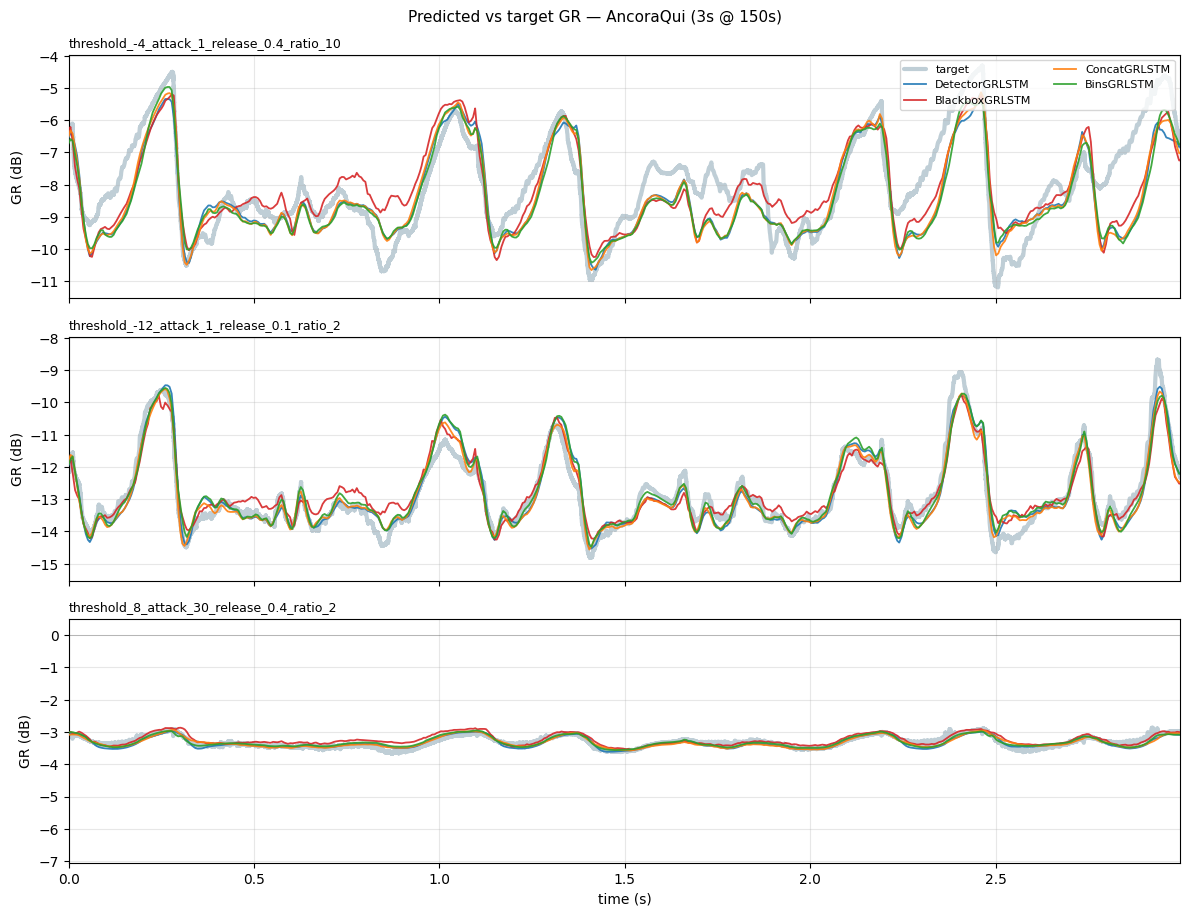

,Setting,"detector (base: FiLM+GLU, regression) MAE (dB)",blackbox (F1: learned frontend) MAE (dB),concat (C1: knob-concat cond) MAE (dB),bins (O1: discretized head) MAE (dB),mean GR MAE (dB)
0,threshold_8_attack_1_release_0.1_ratio_10,0.065,0.061,0.027,0.064,0.054
1,threshold_8_attack_30_release_0.4_ratio_2,0.070,0.094,0.066,0.064,0.073
2,threshold_4_attack_10_release_0.1_ratio_10,0.113,0.088,0.097,0.075,0.093
3,threshold_12_attack_3_release_0.8_ratio_2,0.111,0.132,0.103,0.101,0.112
4,threshold_-4_attack_10_release_0.1_ratio_2,0.161,0.222,0.156,0.200,0.185
5,threshold_-12_attack_1_release_0.1_ratio_2,0.263,0.314,0.243,0.262,0.270
6,threshold_-8_attack_30_release_0.8_ratio_4,0.260,0.327,0.279,0.270,0.284
7,threshold_0_attack_3_release_0.8_ratio_4,0.428,0.508,0.430,0.455,0.455
8,threshold_-12_attack_10_release_0.4_ratio_10,0.541,0.573,0.496,0.484,0.523
9,threshold_-4_attack_1_release_0.4_ratio_10,0.749,0.770,0.729,0.742,0.748


In [15]:
# ── 9. GR-curve predictions on 3 validation settings (all models overlaid) ──

PLOT_SONG = MODEL_REGISTRY["detector"]["split"].val_songs[0]   # held-out for every run
PLOT_START_SEC = 150.0
PLOT_DURATION_SEC = 3.0
PLOT_PRE_ROLL_SEC = 10.0


@torch.no_grad()
def predict_gr_window(model, setting, song, start_sec=PLOT_START_SEC,
                      duration_sec=PLOT_DURATION_SEC, pre_roll_sec=PLOT_PRE_ROLL_SEC):
    """Target + predicted GR (dB) over one window; pre-roll runs in the same causal pass."""
    hop = model.hop_size
    step = hop
    dry_path, wet_path = pair_paths(setting, song)
    params = torch.tensor([normalize_setting_params(setting)], dtype=torch.float32).to(DEVICE)

    start = int(round(start_sec * SR)); stop = start + int(round(duration_sec * SR))
    context_start = max(0, start - int(round(pre_roll_sec * SR)))
    offset = start - context_start

    dry, wet = _read_dry_wet_segment(dry_path, wet_path, context_start, stop, SR)
    L = dry.shape[-1] - (dry.shape[-1] % step)
    dry, wet = dry[..., :L], wet[..., :L]
    gr_true = gain_reduction_db(dry.unsqueeze(0), wet.unsqueeze(0), RMS_WIN)\
        .squeeze(0).clamp(GR_DB_MIN, GR_DB_MAX)

    out = model(dry.unsqueeze(0).to(DEVICE), params)
    gr_pred = model.to_db(out, sample_len=L).squeeze(0)

    n = min(stop - start, L - offset)
    w = slice(offset, offset + n)
    t = np.arange(n) / SR
    return t, gr_true[..., w].squeeze().cpu().numpy(), gr_pred[..., w].squeeze().cpu().numpy()


# rank the val song's settings by mean windowed GR MAE across all models, cache curves
_settings = MODEL_REGISTRY["detector"]["split"].all_settings
_have = [s for s in _settings if all(os.path.isfile(p) for p in pair_paths(s, PLOT_SONG))]
assert _have, f"No settings with local dry/wet for {PLOT_SONG}"

_curves, _rank_rows = {}, []
for s in _have:
    row = {"Setting": s}
    for key, spec in MODEL_REGISTRY.items():
        t, gt, gp = predict_gr_window(spec["model"], s, PLOT_SONG)
        _curves[(s, key)] = (t, gt, gp)
        row[f"{spec['label']} MAE (dB)"] = float(np.mean(np.abs(gp - gt)))
    row["mean GR MAE (dB)"] = float(np.mean([v for k, v in row.items() if k != "Setting"]))
    _rank_rows.append(row)

rank_df = pd.DataFrame(_rank_rows).sort_values("mean GR MAE (dB)").reset_index(drop=True)
rank_df = rank_df.round(3)
chosen_settings = [rank_df.iloc[-1]["Setting"],                 # hardest
                   rank_df.iloc[len(rank_df) // 2]["Setting"],  # median
                   rank_df.iloc[1]["Setting"]]                  # easiest
print(f"Validation song: {PLOT_SONG}   window: {PLOT_START_SEC:.0f}-"
      f"{PLOT_START_SEC + PLOT_DURATION_SEC:.0f} s   ({len(_have)}/{len(_settings)} settings local)")
print("Chosen settings (by mean model GR MAE, high→low):")
for s in chosen_settings:
    print(f"  {s}")

# common y-span (same zoom for every subplot), each centered on its own data
def _setting_vals(setting):
    return np.concatenate([
        np.concatenate([_curves[(setting, key)][1], _curves[(setting, key)][2]])
        for key in MODEL_REGISTRY
    ])

_spans = {s: float(_setting_vals(s).max() - _setting_vals(s).min()) for s in chosen_settings}
YSPAN = max(_spans.values()) * 1.10 + 1e-6   # widest range + 5% pad each side, shared by all

fig, axes = plt.subplots(len(chosen_settings), 1, figsize=(12, 3.1 * len(chosen_settings)),
                         sharex=True, squeeze=False)
for ax, setting in zip(axes[:, 0], chosen_settings):
    target_drawn = False
    for key, spec in MODEL_REGISTRY.items():
        t, gt, gp = _curves[(setting, key)]
        if not target_drawn:
            ax.plot(t, gt, color="#9db4c0", lw=3.0, alpha=0.65, label="target",
                    solid_capstyle="round", zorder=1)   # soft slate, sits behind
            target_drawn = True
        ax.plot(t, gp, color=spec["color"], lw=1.3, alpha=0.9, zorder=3,
                label=type(spec["model"]).__name__)
    ax.axhline(0, color="k", lw=0.5, alpha=0.3)
    ax.set_ylabel("GR (dB)")
    ax.set_title(f"{setting}", fontsize=9, loc="left")
    ax.grid(alpha=0.3)
    ax.set_xlim(t[0], t[-1])   # tight: curves reach both edges
    _sv = _setting_vals(setting)
    _mid = 0.5 * (float(_sv.min()) + float(_sv.max()))   # center on this setting's own data
    ax.set_ylim(_mid - YSPAN / 2, _mid + YSPAN / 2)      # same span everywhere, so no zoom change
axes[0, 0].legend(loc="upper right", fontsize=8, ncol=2)
axes[-1, 0].set_xlabel("time (s)")
fig.suptitle(f"Predicted vs target GR — {PLOT_SONG} "
             f"({PLOT_DURATION_SEC:.0f}s @ {PLOT_START_SEC:.0f}s)", fontsize=11)
plt.tight_layout()
plt.show()

display(rank_df)

## ── 10. Whole-song GR MAE per setting — validation song, all models

The ── 9 table scores only the plotted 3 s window; this one scores the **entire song** at
every locally-available setting. It follows the ── 5 streaming-engine conventions exactly
(10 s state-carried chunks, RMS-smoothed GR via `reference_gr_db`, tail-chunk skip), so each
number matches the "GR MAE (dB)" column of `val_pair_df` — rows already scored in ── 6 are
reused instead of recomputed. Freshly streamed pairs keep only scalar accumulators, so peak
RAM is one 10 s chunk regardless of song length.

In [11]:
# ── 10. Whole-song GR MAE per setting — validation song, all models ──

@torch.no_grad()
def stream_gr_mae(model, song: str, setting: str) -> float:
    """Whole-song frame-weighted GR MAE (dB); chunking identical to stream_pair_metrics."""
    step = model.hop_size
    chunk_frames = max(step, (int(round(STREAM_CHUNK_SEC * SR)) // step) * step)
    dry_path, wet_path = pair_paths(setting, song)
    params = torch.tensor([normalize_setting_params(setting)], dtype=torch.float32).to(DEVICE)
    total = _pair_num_frames(dry_path, wet_path, SR)
    state, err_sum, n_frames = None, 0.0, 0
    for o in range(0, total, chunk_frames):
        dry, wet = _read_dry_wet_segment(dry_path, wet_path, o, min(o + chunk_frames, total), SR)
        L = dry.shape[-1] - (dry.shape[-1] % step)
        if L < step:
            break
        dry, wet = dry[..., :L], wet[..., :L]
        gr, state = model(dry.unsqueeze(0).to(DEVICE), params, state, return_state=True)
        gr_db = model.to_db(gr, sample_len=L).squeeze(0).cpu()
        if L < MIN_METRIC_FRAMES:      # match the ── 5 engine's tail-chunk skip
            continue
        d = dry.squeeze(0).double().numpy()
        w = wet.squeeze(0).double().numpy()
        p = (dry * _db_to_amplitude(gr_db)).squeeze(0).double().numpy()
        gr_tgt  = np.clip(reference_gr_db(d, w), GR_DB_MIN, GR_DB_MAX)
        gr_pred = np.clip(reference_gr_db(d, p), GR_DB_MIN, GR_DB_MAX)
        err_sum += float(np.sum(np.abs(gr_pred - gr_tgt)))
        n_frames += L
        del dry, wet, gr, gr_db, d, w, p, gr_tgt, gr_pred
    return err_sum / max(n_frames, 1)


def _whole_song_gr_mae(spec, song, setting):
    """Reuse the cell ── 6 result when this (song, setting) is a scored val pair."""
    df = spec.get("val_pair_df")
    if df is not None:
        hit = df[(df["Song"] == song) & (df["Setting"] == setting)]
        if len(hit):
            return float(hit["GR MAE (dB)"].iloc[0]), True
    return stream_gr_mae(spec["model"], song, setting), False


_full_rows, _n_reused = [], 0
for i, s in enumerate(_have, start=1):
    row = {"Setting": s}
    for key, spec in MODEL_REGISTRY.items():
        mae, reused = _whole_song_gr_mae(spec, PLOT_SONG, s)
        _n_reused += reused
        row[f"{spec['label']} MAE (dB)"] = mae
    row["mean GR MAE (dB)"] = float(np.mean([v for k, v in row.items() if k != "Setting"]))
    _full_rows.append(row)
    print(f"  [{i}/{len(_have)}] {s}   mean {row['mean GR MAE (dB)']:.3f} dB")
    gc.collect()

full_rank_df = pd.DataFrame(_full_rows).sort_values("mean GR MAE (dB)").reset_index(drop=True)
print(f"\nWhole-song GR MAE — {PLOT_SONG}, {len(_have)} settings "
      f"({_n_reused}/{len(_have) * len(MODEL_REGISTRY)} values reused from cell ── 6)")
display(full_rank_df.round(3))

  [1/10] threshold_-12_attack_10_release_0.4_ratio_10   mean 0.743 dB
  [2/10] threshold_-12_attack_1_release_0.1_ratio_2   mean 0.571 dB
  [3/10] threshold_-4_attack_10_release_0.1_ratio_2   mean 0.303 dB
  [4/10] threshold_-4_attack_1_release_0.4_ratio_10   mean 0.804 dB
  [5/10] threshold_-8_attack_30_release_0.8_ratio_4   mean 0.417 dB
  [6/10] threshold_0_attack_3_release_0.8_ratio_4   mean 0.487 dB
  [7/10] threshold_12_attack_3_release_0.8_ratio_2   mean 0.158 dB
  [8/10] threshold_4_attack_10_release_0.1_ratio_10   mean 0.141 dB
  [9/10] threshold_8_attack_1_release_0.1_ratio_10   mean 0.108 dB
  [10/10] threshold_8_attack_30_release_0.4_ratio_2   mean 0.132 dB

Whole-song GR MAE — AncoraQui, 10 settings (40/40 values reused from cell ── 6)


,Setting,"detector (base: FiLM+GLU, regression) MAE (dB)",blackbox (F1: learned frontend) MAE (dB),concat (C1: knob-concat cond) MAE (dB),bins (O1: discretized head) MAE (dB),mean GR MAE (dB)
0,threshold_8_attack_1_release_0.1_ratio_10,0.118,0.115,0.085,0.115,0.108
1,threshold_8_attack_30_release_0.4_ratio_2,0.141,0.128,0.132,0.127,0.132
2,threshold_4_attack_10_release_0.1_ratio_10,0.167,0.135,0.139,0.123,0.141
3,threshold_12_attack_3_release_0.8_ratio_2,0.163,0.154,0.160,0.156,0.158
4,threshold_-4_attack_10_release_0.1_ratio_2,0.283,0.303,0.301,0.323,0.303
5,threshold_-8_attack_30_release_0.8_ratio_4,0.413,0.423,0.390,0.441,0.417
6,threshold_0_attack_3_release_0.8_ratio_4,0.464,0.467,0.494,0.521,0.487
7,threshold_-12_attack_1_release_0.1_ratio_2,0.576,0.628,0.517,0.562,0.571
8,threshold_-12_attack_10_release_0.4_ratio_10,0.783,0.711,0.741,0.736,0.743
9,threshold_-4_attack_1_release_0.4_ratio_10,0.810,0.766,0.802,0.838,0.804


## ── 11. Whole-song GR MAE — per-setting profile

Visualizes `full_rank_df` from cell ── 10: grouped horizontal bars, one group per setting (sorted easy → hard by mean model MAE), one bar per model. Colours/order are the fixed model identities from the registry (same as cell ── 9).

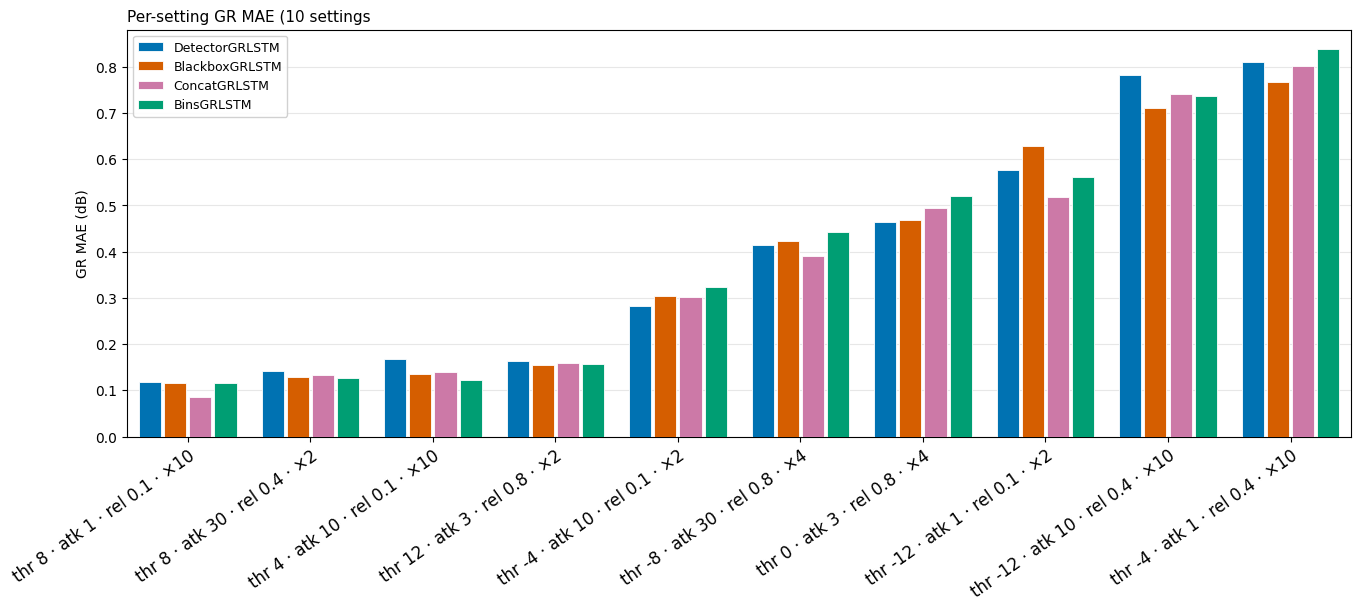

In [16]:
# ── 11. Whole-song GR MAE — per-setting profile ──
import re

# Okabe & Ito (2008) colourblind-safe qualitative palette, keyed by model identity.
# Validated (dataviz palette checker): CVD ΔE >= 17.9 between all pairs.
_PALETTE = {
    "detector": "#0072B2",   # blue
    "blackbox": "#D55E00",   # vermillion
    "concat":   "#CC79A7",   # reddish purple
    "bins":     "#009E73",   # bluish green
}


def _short_setting(s: str) -> str:
    """threshold_-12_attack_10_release_0.4_ratio_10 → 'thr -12 · atk 10 · rel 0.4 · ×10'."""
    d = dict(re.findall(r"(threshold|attack|release|ratio)_(-?\d+(?:\.\d+)?)", s))
    if not d:
        return s
    return (f"thr {d.get('threshold','?')} · atk {d.get('attack','?')} · "
            f"rel {d.get('release','?')} · ×{d.get('ratio','?')}")


# fixed model identity: (dataframe column label, legend label, scientific colour)
_models = [(spec["label"], type(spec["model"]).__name__, _PALETTE[key])
           for key, spec in MODEL_REGISTRY.items()]

_df = full_rank_df.reset_index(drop=True)            # already sorted easy→hard by mean
_n = len(_df)
_x = np.arange(_n)
_n_m = len(_models)
_bar_w = 0.82 / _n_m

fig, ax = plt.subplots(figsize=(max(8.0, 1.15 * _n + 2.0), 6.0), constrained_layout=True)

# grouped vertical bars, one group per setting (easiest → hardest, left → right)
for j, (col_lbl, leg_lbl, color) in enumerate(_models):
    off = (j - (_n_m - 1) / 2) * _bar_w
    ax.bar(_x + off, _df[f"{col_lbl} MAE (dB)"].to_numpy(), width=_bar_w * 0.88,
           color=color, edgecolor="white", linewidth=0.6, label=leg_lbl, zorder=3)
ax.set_xticks(_x)
ax.set_xticklabels([_short_setting(s) for s in _df["Setting"]], fontsize=12,
                   rotation=35, ha="right", rotation_mode="anchor")
ax.set_ylabel("GR MAE (dB)")
ax.set_title(f"Per-setting GR MAE ({_n} settings",
             fontsize=11, loc="left")
ax.grid(axis="y", alpha=0.3, zorder=0)
ax.legend(loc="upper left", fontsize=9, framealpha=0.9)
ax.margins(x=0.01)
plt.show()